# Kidney Disease Prediction with XGBoost

**Algorithm:** XGBoost Classifier  
**Dataset:** kidney_disease.csv  
**Target:** Binary Classification (ckd / notckd)

## Steps
1. Import Libraries
2. Load Dataset
3. EDA
4. Preprocessing
5. Train-Test Split
6. Feature Scaling
7. Model Training
8. Evaluation
9. Save Model
10. Prediction Example



## Step 1: Import Libraries


In [28]:
import os
import sys
import warnings
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
import joblib

warnings.filterwarnings('ignore')

# XGBoost
try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
    print("SUCCESS: XGBoost imported!")
except ImportError:
    XGBOOST_AVAILABLE = False
    print("ERROR: XGBoost not found! Install: pip install xgboost")

# Add utils to path for preprocessing
sys.path.append(os.path.dirname(os.path.abspath('')))
from utils.preprocessing import preprocess_kidney_disease_data

# Visualization (optional)
try:
    import matplotlib.pyplot as plt
    import seaborn as sns
    plt.style.use('seaborn-v0_8')
    VISUALIZATION_AVAILABLE = True
    print("SUCCESS: All libraries imported! (with visualization)")
except ImportError:
    VISUALIZATION_AVAILABLE = False
    print("SUCCESS: All libraries imported! (visualization not available)")



SUCCESS: XGBoost imported!
SUCCESS: All libraries imported! (with visualization)


## Step 2: Load Dataset


In [29]:
dataset_path = 'kidney_disease.csv'

if os.path.exists(dataset_path):
    print(f"Loading dataset: {dataset_path}")
    df = pd.read_csv(dataset_path)

    print(f"\nSUCCESS: Dataset loaded!")
    print(f"   Rows: {df.shape[0]:,}")
    print(f"   Columns: {df.shape[1]}")
    print(f"\nColumn names:")
    print(df.columns.tolist())
    print(f"\nFirst 5 rows:")
    print(df.head())
    print(f"\nDataset Info:")
    print(df.info())

    # Remove duplicates early to avoid leakage
    dup_count = df.duplicated().sum()
    if dup_count > 0:
        print(f"\nWARNING: Found {dup_count} duplicate rows. Dropping duplicates...")
        df = df.drop_duplicates().reset_index(drop=True)
        print(f"   New shape after dropping duplicates: {df.shape}")

    # Standardize target column name
    target_candidates = ['classification', 'Class', 'class', 'target', 'ckd', 'CKD']
    target_col = None
    for col in target_candidates:
        if col in df.columns:
            target_col = col
            break

    if target_col:
        print(f"\nTarget column found: {target_col}")
        if target_col != 'classification':
            df = df.rename(columns={target_col: 'classification'})
    else:
        print("\nWARNING: Target column not found. Please check dataset.")
else:
    raise FileNotFoundError(f"Dataset not found: {dataset_path}")



Loading dataset: kidney_disease.csv

SUCCESS: Dataset loaded!
   Rows: 100,000
   Columns: 26

Column names:
['id', 'age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane', 'classification']

First 5 rows:
   id   age    bp     sg   al   su     rbc        pc         pcc          ba  \
0   0  48.0  80.0  1.020  1.0  0.0     NaN    normal  notpresent  notpresent   
1   1   7.0  50.0  1.020  4.0  0.0     NaN    normal  notpresent  notpresent   
2   2  62.0  80.0  1.010  2.0  3.0  normal    normal  notpresent  notpresent   
3   3  48.0  70.0  1.005  4.0  0.0  normal  abnormal     present  notpresent   
4   4  51.0  80.0  1.010  2.0  0.0  normal    normal  notpresent  notpresent   

   ...  pcv    wc   rc  htn   dm  cad appet   pe  ane classification  
0  ...   44  7800  5.2  yes  yes   no  good   no   no            ckd  
1  ...   38  6000  NaN   no   no   no  good   no   no            ckd 

## Step 3: EDA


DATASET INFORMATION

Shape: (100000, 26)

Data Types:
id                  int64
age               float64
bp                float64
sg                float64
al                float64
su                float64
rbc                object
pc                 object
pcc                object
ba                 object
bgr               float64
bu                float64
sc                float64
sod               float64
pot               float64
hemo              float64
pcv                object
wc                 object
rc                 object
htn                object
dm                 object
cad                object
appet              object
pe                 object
ane                object
classification     object
dtype: object

Missing Values:
251352 total missing values
age       2185
bp        3048
sg       11790
al       11509
su       12245
rbc      38153
pc       16256
pcc        977
ba         977
bgr      10901
bu        4718
sc        4244
sod      21571
pot      21820
h

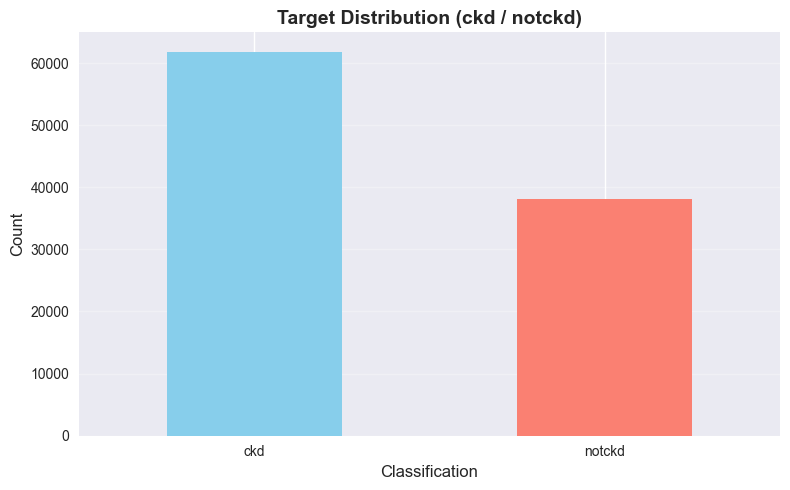

In [30]:
print("=" * 70)
print("DATASET INFORMATION")
print("=" * 70)
print(f"\nShape: {df.shape}")
print(f"\nData Types:")
print(df.dtypes)
print(f"\nMissing Values:")
print(df.isnull().sum().sum(), "total missing values")
missing_cols = df.isnull().sum()[df.isnull().sum() > 0]
if len(missing_cols) > 0:
    print(missing_cols)
print(f"\nDuplicate Rows: {df.duplicated().sum()}")

if 'classification' in df.columns:
    print("=" * 70)
    print("TARGET VARIABLE DISTRIBUTION")
    print("=" * 70)
    target_counts = df['classification'].value_counts()
    target_percent = df['classification'].value_counts(normalize=True) * 100
    print(f"\nCounts:")
    print(target_counts)
    print(f"\nPercentages:")
    print(target_percent)

    if VISUALIZATION_AVAILABLE:
        plt.figure(figsize=(8, 5))
        target_counts.plot(kind='bar', color=['skyblue', 'salmon'])
        plt.title('Target Distribution (ckd / notckd)', fontsize=14, fontweight='bold')
        plt.xlabel('Classification', fontsize=12)
        plt.ylabel('Count', fontsize=12)
        plt.xticks(rotation=0)
        plt.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()
else:
    print("ERROR: Target column not found!")



## Step 4: Preprocessing


In [31]:
print("=" * 70)
print("DATA PREPROCESSING")
print("=" * 70)
print("\nSplitting raw data first to avoid leakage...")

# Clean target on raw data
if 'classification' not in df.columns:
    raise ValueError("Target column 'classification' not found.")

df = df.copy()
df['classification'] = df['classification'].astype(str).str.strip().str.replace('\t', '').str.lower()

print("\nRaw target unique values (before split):")
print(df['classification'].value_counts().head(10))

# Train-test split on raw data
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['classification']
)

print(f"\nTrain rows: {train_df.shape[0]:,}")
print(f"Test rows:  {test_df.shape[0]:,}")

# Preprocess train/test separately using train statistics

def preprocess_split(train_df: pd.DataFrame, test_df: pd.DataFrame):
    # Drop id if present
    if 'id' in train_df.columns:
        train_df = train_df.drop(columns=['id'])
    if 'id' in test_df.columns:
        test_df = test_df.drop(columns=['id'])

    # Separate target
    y_train_raw = train_df['classification'].copy()
    y_test_raw = test_df['classification'].copy()
    X_train = train_df.drop(columns=['classification'])
    X_test = test_df.drop(columns=['classification'])

    # Identify columns
    cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()
    num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

    # Impute numeric with train median
    medians = X_train[num_cols].median()
    X_train[num_cols] = X_train[num_cols].fillna(medians)
    X_test[num_cols] = X_test[num_cols].fillna(medians)

    # Fill categorical missing
    X_train[cat_cols] = X_train[cat_cols].fillna('unknown')
    X_test[cat_cols] = X_test[cat_cols].fillna('unknown')

    # Encode categorical with train-fitted encoders
    encoders = {}
    for col in cat_cols:
        le = LabelEncoder()
        le.fit(X_train[col].astype(str))
        encoders[col] = le
        X_train[col] = le.transform(X_train[col].astype(str))

        # Handle unseen labels in test
        test_vals = X_test[col].astype(str)
        known = set(le.classes_)
        X_test[col] = test_vals.apply(lambda v: le.transform([v])[0] if v in known else -1)

    return X_train, X_test, y_train_raw, y_test_raw, encoders

X_train_raw, X_test_raw, y_train_raw, y_test_raw, encoders = preprocess_split(train_df, test_df)

print("\nSUCCESS: Preprocessing completed!")
print(f"   X_train shape: {X_train_raw.shape}")
print(f"   X_test shape:  {X_test_raw.shape}")



DATA PREPROCESSING

Splitting raw data first to avoid leakage...

Raw target unique values (before split):
classification
ckd       61851
notckd    38149
Name: count, dtype: int64

Train rows: 80,000
Test rows:  20,000

SUCCESS: Preprocessing completed!
   X_train shape: (80000, 24)
   X_test shape:  (20000, 24)


In [32]:
print("\nPreparing features and target...")

X = X_train_raw.copy()
X_test = X_test_raw.copy()

print("   Converting target to binary format...")

def normalize_target(series: pd.Series) -> pd.Series:
    cleaned = series.astype(str).str.strip().str.replace('\t', '').str.lower()
    mapping = {
        'ckd': 1,
        'notckd': 0,
        '1': 1,
        '0': 0,
        'yes': 1,
        'no': 0,
        'true': 1,
        'false': 0
    }
    mapped = cleaned.map(mapping)
    if mapped.isnull().any():
        numeric = pd.to_numeric(cleaned, errors='coerce')
        if numeric.notna().any():
            mapped = (numeric.fillna(0) > 0).astype(int)
        else:
            mapped = mapped.fillna(0).astype(int)
    return mapped.astype(int)

# Normalize train/test targets using same mapping

y_train = normalize_target(y_train_raw)
y_test = normalize_target(y_test_raw)

print(f"\n   Features shape (train): {X.shape}")
print(f"   Features shape (test):  {X_test.shape}")
print(f"   Target shape (train):   {y_train.shape}")
print(f"   Target shape (test):    {y_test.shape}")
print(f"   Target distribution (train): {y_train.value_counts().to_dict()}")
print(f"   Target distribution (test):  {y_test.value_counts().to_dict()}")

if y_train.nunique() < 2 or y_test.nunique() < 2:
    raise ValueError("Target has only one class after preprocessing. Check label mapping/data.")

print("\nSUCCESS: Features and target prepared!")




Preparing features and target...
   Converting target to binary format...

   Features shape (train): (80000, 24)
   Features shape (test):  (20000, 24)
   Target shape (train):   (80000,)
   Target shape (test):    (20000,)
   Target distribution (train): {1: 49481, 0: 30519}
   Target distribution (test):  {1: 12370, 0: 7630}

SUCCESS: Features and target prepared!


## Step 5: Train-Test Split


In [33]:
print("=" * 70)
print("TRAIN-TEST SPLIT")
print("=" * 70)

# Already split in preprocessing step
print(f"\nTraining set:")
print(f"   X_train shape: {X.shape}")
print(f"   y_train shape: {y_train.shape}")
print(f"   y_train distribution: {y_train.value_counts().to_dict()}")

print(f"\nTest set:")
print(f"   X_test shape: {X_test.shape}")
print(f"   y_test shape: {y_test.shape}")
print(f"   y_test distribution: {y_test.value_counts().to_dict()}")

print("\nSUCCESS: Train-test split completed!")



TRAIN-TEST SPLIT

Training set:
   X_train shape: (80000, 24)
   y_train shape: (80000,)
   y_train distribution: {1: 49481, 0: 30519}

Test set:
   X_test shape: (20000, 24)
   y_test shape: (20000,)
   y_test distribution: {1: 12370, 0: 7630}

SUCCESS: Train-test split completed!


## Step 6: Feature Scaling


In [34]:
print("=" * 70)
print("FEATURE SCALING")
print("=" * 70)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test)

print("\nSUCCESS: Features scaled!")
print(f"   Training set scaled: {X_train_scaled.shape}")
print(f"   Test set scaled: {X_test_scaled.shape}")



FEATURE SCALING

SUCCESS: Features scaled!
   Training set scaled: (80000, 24)
   Test set scaled: (20000, 24)


## Step 7: Model Training (XGBoost)


In [35]:
if not XGBOOST_AVAILABLE:
    raise ImportError("XGBoost not available. Install: pip install xgboost")

print("=" * 70)
print("XGBOOST MODEL TRAINING")
print("=" * 70)

print("\nFinal target check before training:")
print(f"   Training target unique: {y_train.unique()}")
print(f"   Training target distribution: {y_train.value_counts().to_dict()}")

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    base_score=0.5
)

print("\nTraining model...")
xgb_model.fit(X_train_scaled, y_train)

print("\nSUCCESS: Model training completed!")



XGBOOST MODEL TRAINING

Final target check before training:
   Training target unique: [0 1]
   Training target distribution: {1: 49481, 0: 30519}

Training model...

SUCCESS: Model training completed!


## Step 8: Evaluation


MODEL EVALUATION

ACCURACY RESULTS:
   Training Accuracy: 0.9705 (97.05%)
   Test Accuracy:     0.9704 (97.04%)

   Overfitting Gap:   0.0001
   GOOD: Model generalizes well!

CROSS-VALIDATION SCORE:
   CV Scores: [0.9706875 0.970625  0.970125  0.97025   0.97025  ]
   Mean CV Accuracy: 0.9704 (97.04%)
   Std CV Accuracy:  0.0002 (+/- 0.0005)

CLASSIFICATION REPORT (Test Set):
              precision    recall  f1-score   support

      No CKD       0.97      0.95      0.96      7630
         CKD       0.97      0.98      0.98     12370

    accuracy                           0.97     20000
   macro avg       0.97      0.97      0.97     20000
weighted avg       0.97      0.97      0.97     20000


CONFUSION MATRIX (Test Set):
[[ 7266   364]
 [  228 12142]]


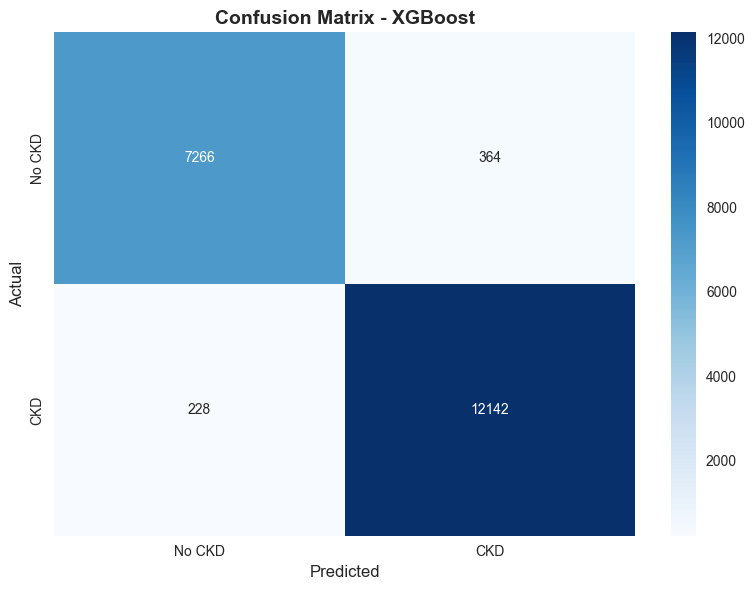


ROC-AUC SCORE:
   ROC-AUC: 0.9661 (96.61%)


In [36]:
print("=" * 70)
print("MODEL EVALUATION")
print("=" * 70)

y_train_pred = xgb_model.predict(X_train_scaled)
y_test_pred = xgb_model.predict(X_test_scaled)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

overfitting_gap = train_accuracy - test_accuracy

print(f"\nACCURACY RESULTS:")
print(f"   Training Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"   Test Accuracy:     {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"\n   Overfitting Gap:   {overfitting_gap:.4f}")

if overfitting_gap > 0.15:
    print("   WARNING: Potential overfitting detected!")
elif overfitting_gap < 0.05:
    print("   GOOD: Model generalizes well!")
else:
    print("   ACCEPTABLE: Model performance is reasonable")

print("\nCROSS-VALIDATION SCORE:")
cv_scores = cross_val_score(xgb_model, X_train_scaled, y_train, cv=5, scoring='accuracy')
print(f"   CV Scores: {cv_scores}")
print(f"   Mean CV Accuracy: {cv_scores.mean():.4f} ({cv_scores.mean()*100:.2f}%)")
print(f"   Std CV Accuracy:  {cv_scores.std():.4f} (+/- {cv_scores.std()*2:.4f})")

print("\nCLASSIFICATION REPORT (Test Set):")
print("=" * 70)
print(classification_report(y_test, y_test_pred, target_names=['No CKD', 'CKD']))

print("\nCONFUSION MATRIX (Test Set):")
print("=" * 70)
cm = confusion_matrix(y_test, y_test_pred)
print(cm)

if VISUALIZATION_AVAILABLE:
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No CKD', 'CKD'],
                yticklabels=['No CKD', 'CKD'])
    plt.title('Confusion Matrix - XGBoost', fontsize=14, fontweight='bold')
    plt.ylabel('Actual', fontsize=12)
    plt.xlabel('Predicted', fontsize=12)
    plt.tight_layout()
    plt.show()

# ROC-AUC
try:
    y_test_proba = xgb_model.predict_proba(X_test_scaled)[:, 1]
    roc_auc = roc_auc_score(y_test, y_test_proba)
    print(f"\nROC-AUC SCORE:")
    print(f"   ROC-AUC: {roc_auc:.4f} ({roc_auc*100:.2f}%)")
except Exception as e:
    print(f"\nWARNING: Could not calculate ROC-AUC: {e}")



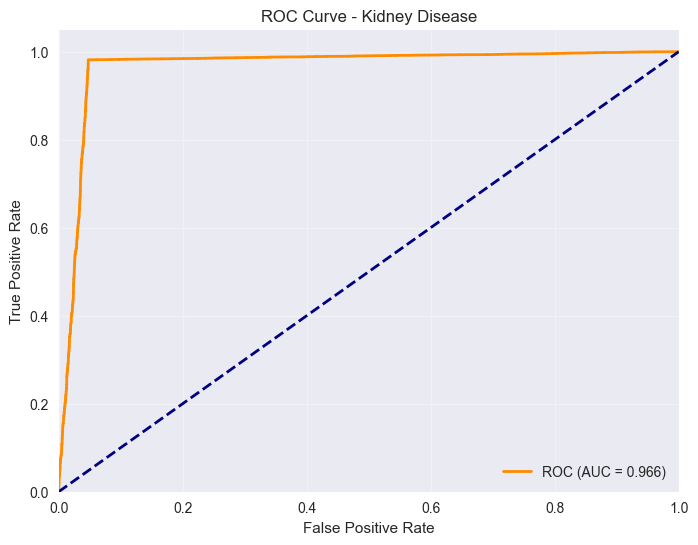

Best threshold (Youden Index): 0.6592


In [37]:
# ROC Curve + Youden Index (Best Threshold)
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
roc_auc_val = auc(fpr, tpr)

if VISUALIZATION_AVAILABLE:
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc_val:.3f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
    plt.title('ROC Curve - Kidney Disease'); plt.legend(loc='lower right'); plt.grid(alpha=0.3); plt.show()

youden_idx = np.argmax(tpr - fpr)
best_threshold = float(thresholds[youden_idx])
print(f"Best threshold (Youden Index): {best_threshold:.4f}")


## Step 9: Save Model


In [38]:
import json

print("=" * 70)
print("SAVING MODEL")
print("=" * 70)

model_path = '../backend/ml_models/kidney_disease_model.pkl'
scaler_path = '../backend/ml_models/kidney_disease_scaler.pkl'
encoders_path = '../backend/ml_models/kidney_disease_encoders.pkl'
threshold_path = '../backend/ml_models/threshold.json'

joblib.dump(xgb_model, model_path)
joblib.dump(scaler, scaler_path)
joblib.dump(encoders, encoders_path)

thresh_data = {}
if os.path.exists(threshold_path):
    with open(threshold_path) as f:
        thresh_data = json.load(f)
thresh_data["kidney_disease"] = best_threshold
with open(threshold_path, "w") as f:
    json.dump(thresh_data, f, indent=2)

print("\nSUCCESS: Model saved successfully!")
print(f"   Model Path: {model_path}")
print(f"   Scaler Path: {scaler_path}")
print(f"   Encoders: {encoders_path}")
print(f"   Threshold: {threshold_path} (kidney_disease={best_threshold:.4f})")
print(f"   Model Type: XGBoost Classifier")
print(f"   Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")



SAVING MODEL

SUCCESS: Model saved successfully!
   Model Path: ../backend/ml_models/kidney_disease_model.pkl
   Scaler Path: ../backend/ml_models/kidney_disease_scaler.pkl
   Encoders: ../backend/ml_models/kidney_disease_encoders.pkl
   Threshold: ../backend/ml_models/threshold.json (kidney_disease=0.6592)
   Model Type: XGBoost Classifier
   Test Accuracy: 0.9704 (97.04%)


## Step 10: Prediction Example


In [39]:
print("=" * 70)
print("PREDICTION EXAMPLE")
print("=" * 70)

# Take a sample from test set
sample_idx = 0
sample_data = X_test.iloc[sample_idx:sample_idx + 1]
sample_actual = y_test.iloc[sample_idx]

print("\nSample Patient Data:")
print(sample_data)

# Scale the sample
sample_scaled = scaler.transform(sample_data)

# Make prediction
prediction = xgb_model.predict(sample_scaled)[0]
prediction_proba = xgb_model.predict_proba(sample_scaled)[0]

print("\nPrediction Results:")
print(f"   Predicted: {'CKD' if prediction == 1 else 'No CKD'}")
print(f"   Actual: {'CKD' if sample_actual == 1 else 'No CKD'}")
print(f"   Probability (No CKD): {prediction_proba[0]:.4f} ({prediction_proba[0]*100:.2f}%)")
print(f"   Probability (CKD): {prediction_proba[1]:.4f} ({prediction_proba[1]*100:.2f}%)")
print(f"   Correct: {'YES' if prediction == sample_actual else 'NO'}")

print("\nTo make predictions on new data:")
print("1. Load model: model = joblib.load('backend/ml_models/kidney_disease_model.pkl')")
print("2. Load scaler: scaler = joblib.load('backend/ml_models/kidney_disease_scaler.pkl')")
print("3. Prepare data with same features as training")
print("4. Scale: data_scaled = scaler.transform(data)")
print("5. Predict: prediction = model.predict(data_scaled)")
print("=" * 70)



PREDICTION EXAMPLE

Sample Patient Data:
        age    bp   sg   al   su  rbc  pc  pcc  ba    bgr  ...  hemo  pcv  wc  \
45560  60.0  68.7  1.0  0.0  0.0    1   1    0   0  130.0  ...  13.7   34  62   

       rc  htn  dm  cad  appet  pe  ane  
45560  26    0   3    1      0   0    0  

[1 rows x 24 columns]

Prediction Results:
   Predicted: No CKD
   Actual: No CKD
   Probability (No CKD): 0.9726 (97.26%)
   Probability (CKD): 0.0274 (2.74%)
   Correct: YES

To make predictions on new data:
1. Load model: model = joblib.load('backend/ml_models/kidney_disease_model.pkl')
2. Load scaler: scaler = joblib.load('backend/ml_models/kidney_disease_scaler.pkl')
3. Prepare data with same features as training
4. Scale: data_scaled = scaler.transform(data)
5. Predict: prediction = model.predict(data_scaled)
